In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cybersecurity/cicids_static_data.csv
/kaggle/input/cybersecurity/iot_static_data.csv


# Loading and Investgating Dataset

**1- Importing Dataset**

In [2]:
data = '../input/cybersecurity/iot_static_data.csv'

df = pd.read_csv(data)

In [3]:
print("shape of dataset : " ,df.shape)

shape of dataset :  (25609, 117)


**2- Exploring the dataset**

In [4]:
df.head()

,MI_dir_L5_weight,MI_dir_L5_mean,MI_dir_L5_variance,MI_dir_L3_weight,MI_dir_L3_mean,MI_dir_L3_variance,MI_dir_L1_weight,MI_dir_L1_mean,MI_dir_L1_variance,MI_dir_L0.1_weight,...,HpHp_L0.1_pcc,HpHp_L0.01_weight,HpHp_L0.01_mean,HpHp_L0.01_std,HpHp_L0.01_magnitude,HpHp_L0.01_radius,HpHp_L0.01_covariance,HpHp_L0.01_pcc,Source,Class
0,19.570634,152.679121,39991.937640,20.937891,150.455024,38960.674060,23.168006,145.454142,36954.215040,33.115077,...,0.468843,4.999756,181.799689,2.276210e+02,290.439555,5.957202e+04,1.831480e+04,4.692557e-01,Provision PT 838 Security Camera,BENIGN
1,49.893840,169.297843,54532.338720,62.957476,169.735104,54283.995040,82.340884,168.919514,53449.819730,98.214224,...,0.000000,1.999960,69.999921,4.000000e+00,101.862598,1.600000e+01,0.000000e+00,0.000000e+00,Provision PT 737E Security Camera,BENIGN
2,1.996527,449.011775,409.365474,2.002395,448.141152,739.076602,2.166552,419.128740,11039.485060,4.621621,...,0.000000,14.978833,455.354366,1.959295e+01,455.354366,3.838837e+02,0.000000e+00,0.000000e+00,Samsung SNH 1011 N Webcam,BENIGN
3,1.000000,60.000018,0.004849,1.000065,60.017569,4.743299,1.063813,76.195918,4110.590208,2.936177,...,0.000000,7.290294,60.000000,9.540000e-07,84.852814,1.290000e-12,8.690000e-30,9.560000e-18,SimpleHome XCS7 1002 WHT Security Camera,BENIGN
4,100.707918,226.708372,54562.182272,155.736482,252.269792,58012.457557,446.854937,301.030305,60959.734097,4257.526218,...,0.000000,1.000000,554.000000,0.000000e+00,554.000000,0.000000e+00,0.000000e+00,0.000000e+00,Provision PT 838 Security Camera,mirai_udp_attack


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25609 entries, 0 to 25608
Columns: 117 entries, MI_dir_L5_weight to Class
dtypes: float64(115), object(2)
memory usage: 22.9+ MB


In [6]:
df.describe()

,MI_dir_L5_weight,MI_dir_L5_mean,MI_dir_L5_variance,MI_dir_L3_weight,MI_dir_L3_mean,MI_dir_L3_variance,MI_dir_L1_weight,MI_dir_L1_mean,MI_dir_L1_variance,MI_dir_L0.1_weight,...,HpHp_L0.1_radius,HpHp_L0.1_covariance,HpHp_L0.1_pcc,HpHp_L0.01_weight,HpHp_L0.01_mean,HpHp_L0.01_std,HpHp_L0.01_magnitude,HpHp_L0.01_radius,HpHp_L0.01_covariance,HpHp_L0.01_pcc
count,25609.000000,25609.000000,2.560900e+04,25609.000000,25609.000000,2.560900e+04,25609.000000,25609.000000,25609.000000,25609.000000,...,2.560900e+04,2.560900e+04,2.560900e+04,25609.000000,25609.000000,2.560900e+04,25609.000000,2.560900e+04,2.560900e+04,25609.000000
mean,16.458215,138.570936,7.768559e+03,24.703832,138.614095,8.279129e+03,64.260234,139.362935,9213.286937,555.191870,...,9.737206e+03,8.883111e+02,1.836737e-02,15.419695,138.774908,2.331401e+01,181.843879,1.152385e+04,8.871102e+02,0.028415
std,41.087239,129.673709,2.668021e+04,64.930734,126.663855,2.694292e+04,183.925917,122.343522,26326.030024,1694.895744,...,4.675494e+04,6.214110e+03,1.686189e-01,273.481167,140.555584,6.441393e+01,166.863690,4.927406e+04,7.054763e+03,0.184214
min,1.000000,60.000000,0.000000e+00,1.000000,60.000000,0.000000e+00,1.000000,60.000000,0.000000,1.000000,...,0.000000e+00,-8.584038e+04,-1.551473e+00,1.000000,60.000000,0.000000e+00,60.000000,0.000000e+00,-1.812996e+05,-1.692781
25%,1.000001,66.000000,9.090000e-13,1.000236,66.000000,1.770000e-09,1.128262,66.043013,0.098128,3.430610,...,4.550000e-13,-2.150000e-19,-2.770000e-17,2.999914,66.021257,6.740000e-07,84.852814,9.090000e-13,-2.530000e-29,0.000000
50%,1.594794,81.663628,6.869070e-04,1.819242,81.747426,2.517763e-01,2.026690,84.299338,41.591685,8.311976,...,2.590000e-06,0.000000e+00,0.000000e+00,5.824137,75.000000,8.972650e-02,115.133698,1.600000e+01,0.000000e+00,0.000000
75%,2.999965,148.752850,1.814097e+02,3.139729,150.499727,3.631427e+02,4.005944,147.252315,1930.709057,12.569276,...,2.234147e+02,1.130000e-38,0.000000e+00,17.515348,102.000000,9.846490e+00,144.249783,2.521173e+02,5.000000e-06,0.000016
max,349.606606,1451.207170,4.888213e+05,516.761693,1448.606519,4.731581e+05,1090.951084,1433.998154,457995.701700,8903.129283,...,4.721643e+05,1.309683e+05,2.669061e+00,25682.418417,1470.000000,6.810012e+02,1470.000000,4.795595e+05,1.311862e+05,2.721607


In [7]:
def initial_eda(df):
    if isinstance(df, pd.DataFrame):
        total_na = df.isna().sum().sum()
        print("Dimensions : %d rows, %d columns" % (df.shape[0], df.shape[1]))
        print("Total NA Values : %d " % (total_na))
        print("%38s %10s     %10s %10s" % ("Column Name", "Data Type", "#Distinct", "NA Values"))
        col_name = df.columns
        dtyp = df.dtypes
        uniq = df.nunique()
        na_val = df.isna().sum()
        for i in range(len(df.columns)):
            print("%38s %10s   %10s %10s" % (col_name[i], dtyp[i], uniq[i], na_val[i]))
        
    else:
        print("Expect a DataFrame but got a %15s" % (type(df)))

In [8]:
initial_eda(df)

Dimensions : 25609 rows, 117 columns
Total NA Values : 0 
                           Column Name  Data Type      #Distinct  NA Values
                      MI_dir_L5_weight    float64        18246          0
                        MI_dir_L5_mean    float64        13695          0
                    MI_dir_L5_variance    float64        15566          0
                      MI_dir_L3_weight    float64        20955          0
                        MI_dir_L3_mean    float64        16953          0
                    MI_dir_L3_variance    float64        18577          0
                      MI_dir_L1_weight    float64        23190          0
                        MI_dir_L1_mean    float64        22531          0
                    MI_dir_L1_variance    float64        23618          0
                    MI_dir_L0.1_weight    float64        24583          0
                      MI_dir_L0.1_mean    float64        24401          0
                  MI_dir_L0.1_variance    float64   

In [9]:
df["Class"].value_counts()

BENIGN                   22287
mirai_udp_attack          1774
gafgyt_udp_attack          446
gafgyt_junk_attack         377
gafgyt_tcp_attack          213
gafgyt_scan_attack         200
mirai_syn_attack           101
mirai_ack_attack            96
mirai_scan_attack           86
gafgyt_combo_attack         18
mirai_udpplain_attack       11
Name: Class, dtype: int64

In [10]:
df["Class"].unique()

array(['BENIGN', 'mirai_udp_attack', 'mirai_ack_attack',
       'gafgyt_scan_attack', 'mirai_scan_attack', 'gafgyt_tcp_attack',
       'gafgyt_udp_attack', 'gafgyt_junk_attack', 'gafgyt_combo_attack',
       'mirai_syn_attack', 'mirai_udpplain_attack'], dtype=object)

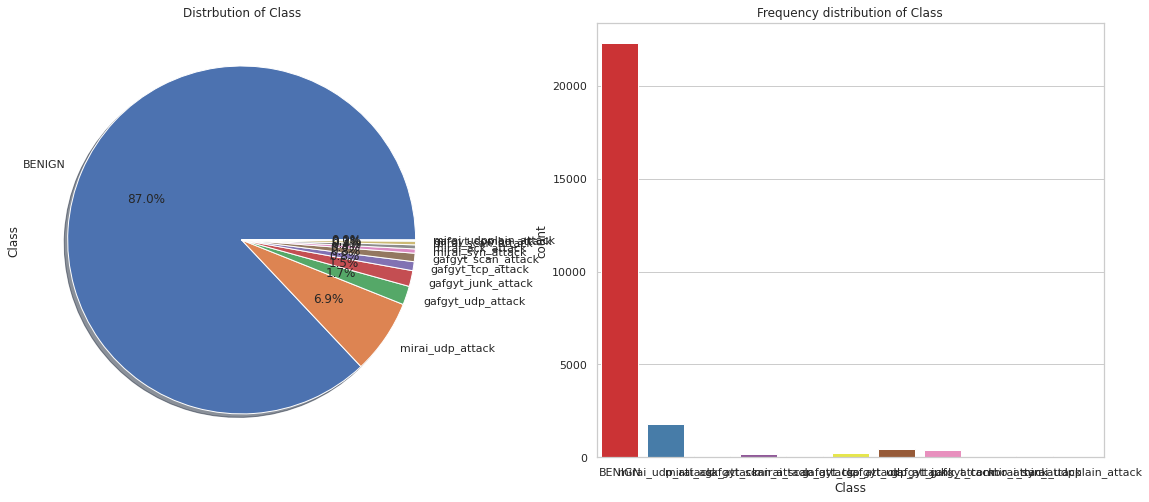

In [11]:
# visualize frequency distribution of Lable 

f,ax=plt.subplots(1,2,figsize=(20,8))

ax[0] = df['Class'].value_counts().plot.pie(explode=None,autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('Distrbution of Class')


#f, ax = plt.subplots(figsize=(6, 8))
ax[1] = sns.countplot(x="Class", data=df, palette="Set1")
ax[1].set_title("Frequency distribution of Class")

plt.show()

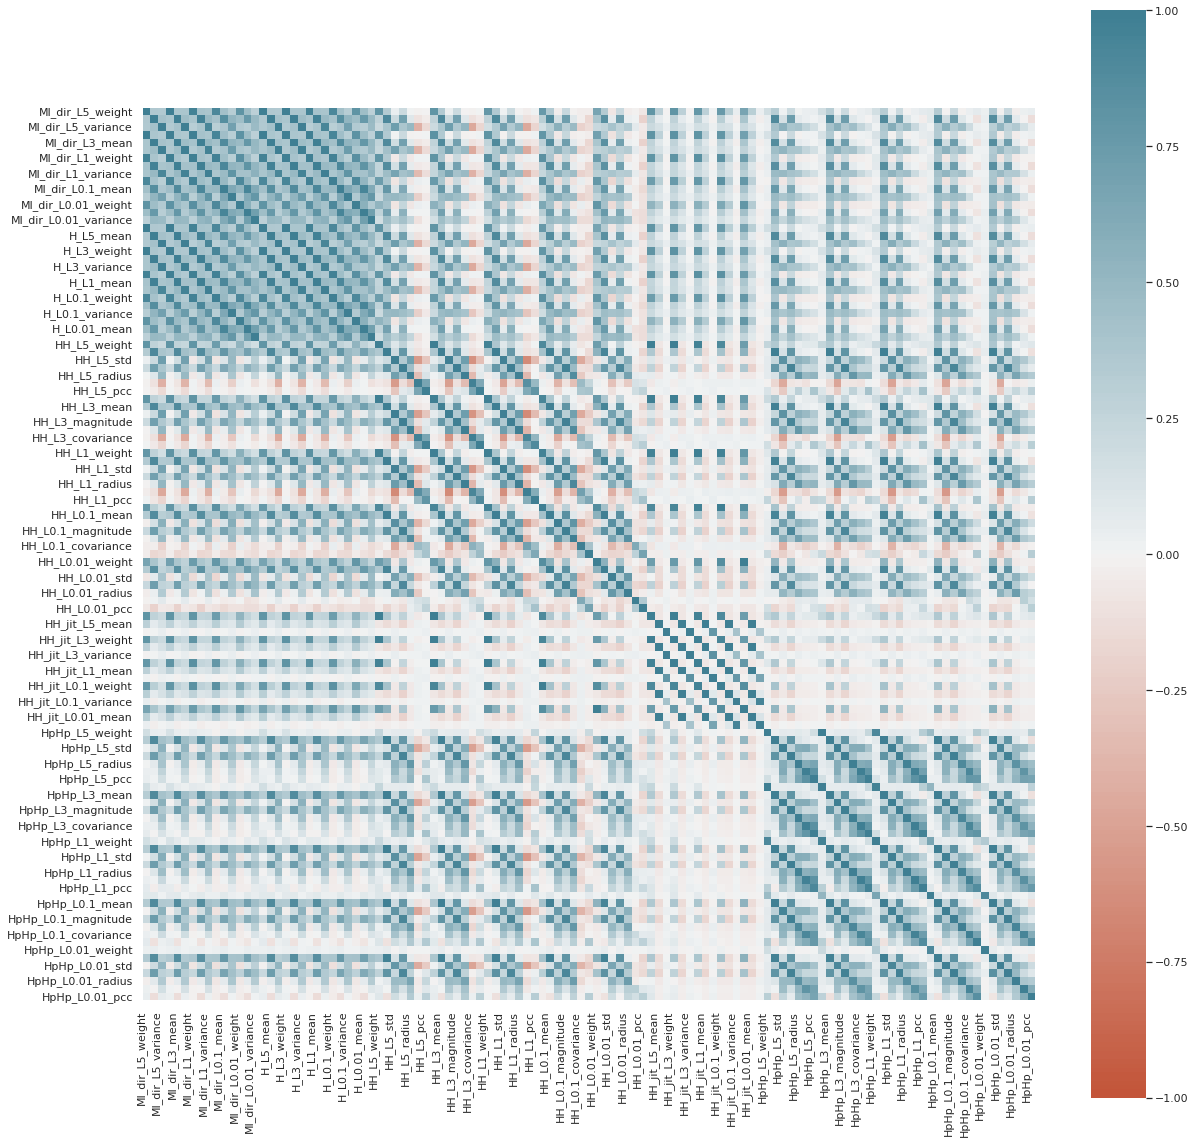

In [12]:
corr = df.corr()
sns.set(rc = {'figure.figsize':(20,20)})
ax = sns.heatmap(
    corr, 
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=90,
    horizontalalignment='right'
);

In [13]:
categorical = [col for col in df.columns if df[col].dtypes == 'O']

categorical

['Source', 'Class']

In [14]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df["Class"] = encoder.fit_transform(df["Class"])
df["Source"].unique()

array(['Provision PT 838 Security Camera',
       'Provision PT 737E Security Camera', 'Samsung SNH 1011 N Webcam',
       'SimpleHome XCS7 1002 WHT Security Camera',
       'Philips B120N10 Baby Monitor',
       'SimpleHome XCS7 1003 WHT Security Camera', 'Ennio Doorbell',
       'Danmini Doorbell', 'Ecobee Thermostat'], dtype=object)

# Label Encoding

In [15]:
df["Source"] = encoder.fit_transform(df["Source"])

# Specifiying Feature Vector and Target Label

In [16]:
X = df.drop(['Class'], axis=1)

y = df['Class']

# Handling Unbalanced Class

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

# Feature Importance and Modeling

**As seen in the perivious figures the data is unbalanced so I decided to use RandomForestClassifier as it's good in handeling the unbalanced classes and we will explore in the following cells**

In [18]:
# import Random Forest classifier
from sklearn.ensemble import RandomForestClassifier
# create the classifier with n_estimators = 100

clf = RandomForestClassifier(n_estimators=100, random_state=0)



# fit the model to the training set

clf.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [19]:
feature_scores = pd.Series(clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

feature_scores

MI_dir_L0.01_weight      0.088877
H_L3_weight              0.060131
MI_dir_L0.1_weight       0.058932
H_L0.1_weight            0.055561
MI_dir_L3_weight         0.044722
                           ...   
HpHp_L5_covariance       0.000000
HpHp_L5_radius           0.000000
HH_L0.01_covariance      0.000000
HpHp_L0.01_covariance    0.000000
HpHp_L0.01_pcc           0.000000
Length: 116, dtype: float64

**Visualizing Feature Importance**

Text(0, 0.5, 'FEATURE NAMES')

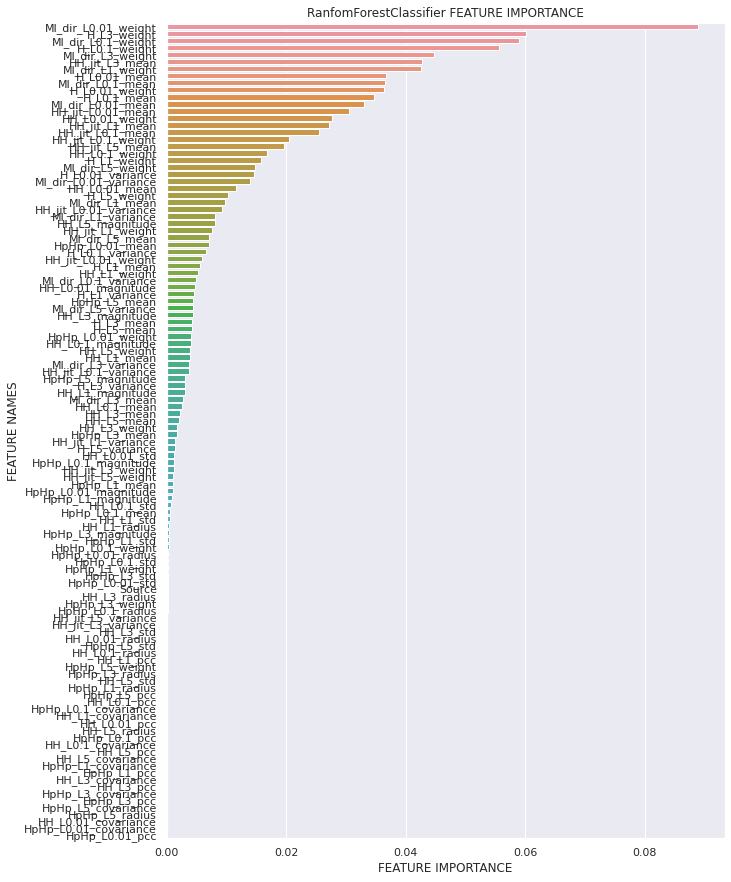

In [20]:
# Creating a seaborn bar plot

#Create a DataFrame using a Dictionary
data={'feature_names':feature_scores.index,'feature_importance':feature_scores}
feature_importance = pd.DataFrame(data)

#Sort the DataFrame in order decreasing feature importance
feature_importance.sort_values(by=['feature_importance'], ascending=False,inplace=True)

#Define size of bar plot
plt.figure(figsize=(10,15))
#Plot Searborn bar chart
sns.barplot(x=feature_importance['feature_importance'], y=feature_importance['feature_names'])
#Add chart labels
plt.title('RanfomForestClassifier FEATURE IMPORTANCE')
plt.xlabel('FEATURE IMPORTANCE')
plt.ylabel('FEATURE NAMES')

In [21]:
features = feature_scores[feature_scores >= 0.03].index

In [22]:
df_filtered = X[features]

In [23]:
df_filtered.shape

(25609, 13)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(df_filtered, y, test_size = 0.3, random_state = 0)

In [25]:
# instantiate the classifier with n_estimators = 100
from sklearn.metrics import accuracy_score, classification_report

clf = RandomForestClassifier(n_estimators=100, random_state=0)



# fit the model to the training set

clf.fit(X_train, y_train)


# Predict on the test set results

y_pred = clf.predict(X_test)



# Check accuracy score 

print('Model accuracy score with selected features : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))
print(classification_report(y_pred,y_test))

Model accuracy score with selected features : 0.9983
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6639
           1       0.20      1.00      0.33         1
           2       0.98      0.97      0.97       115
           3       1.00      1.00      1.00        60
           4       0.98      0.98      0.98        63
           5       1.00      0.99      1.00       143
           6       0.91      0.94      0.93        34
           7       0.96      1.00      0.98        26
           8       1.00      1.00      1.00        33
           9       1.00      1.00      1.00       566
          10       0.33      0.33      0.33         3

    accuracy                           1.00      7683
   macro avg       0.85      0.93      0.87      7683
weighted avg       1.00      1.00      1.00      7683



**As shown above the accuracy and f1-score prove that using RandomForestClassifier came with good results as shown**